# 5. GBM
부스팅 알고리즘: 여러 개의 약한 학습기를 순차적으로 학습/예측 하면서 잘못 예측한 데이터에 가중치 부여하여 오류 개선
### AdaBoost
: 오류 데이터에 가중치 부여하며 반복 학습한 학습기 결합
### GBM
: 에이다부스트와 유사, 가중치 업데이트를 경사 하강법으로. 결괏값 y, 피처 xn, 예측함수 F(x), 오류식 h(x)=y-F(x)을 최소화하는 방향성으로 반복 가중치 업데이트

: CART 기반 다른 알고리즘처럼 분류, 회귀 가능. GradientBoostingClassifier 클래스. > 사용자 행동 데이터 세트 예측 분류.

이전에 진행한 get_human_dataset() 가져오기

In [3]:
import pandas as pd

def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
        lambda x: x[0] + '_' + str(x[1]) if x[1] > 0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

import pandas as pd

def get_human_dataset():
    
    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                        header=None, names=['column_index','column_name'])
    
    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성. 
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)
    
    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv('./human_activity/train/y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt', sep='\s+', header=None, names=['action'])
    
    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test

In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정. 시작 시간 설정.
start_time = time.time()

# GBM 기본 파라미터로 학습 — 랜덤 포레스트보다 일반적으로 높은 성능이나 학습 시간이 김
gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초 ".format(time.time() - start_time))

GBM 정확도: 0.9376
GBM 수행 시간: 2258.6 초 


> **결과 해석**: GBM은 랜덤 포레스트보다 정확도가 높게 나오는 경우가 많지만 수행 시간이 현저히 김.  
> 순차적으로 트리를 쌓는 구조상 병렬화가 어렵기 때문. → XGBoost, LightGBM이 이 문제를 개선.

# 6. XGBoost
: GBM 기반, GBM의 단점인 느린 수행 시간 및 과적합 규제 부재 등의 문제 해결
병렬 CPU환경에서 병렬 학습이 가능해 기존 GBM보다 빠르게 학습 가능.

초기의 독자적인 XGBoost 프레임워크 기반의 XGBoost를 '파이썬 래퍼 XGBoost 모듈', 사이킷런과 연동되는 모듈을 '사이킷런 래퍼 XGBoost 모듈'이라고 지칭.

In [44]:
# XGBoost 설치
!pip install xgboost==1.5.0

  Using cached xgboost-1.5.0-py3-none-win_amd64.whl.metadata (1.7 kB)
Using cached xgboost-1.5.0-py3-none-win_amd64.whl (106.6 MB)
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [45]:
#설치 확인
import xgboost as xgb
from xgboost import XGBClassifier

In [46]:
#버전 확인
import xgboost
print(xgboost.__version__)

1.5.0


In [47]:
#파이썬 래퍼 XGBoost 적용- 위스콘신 유방암 예측
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

# 유방암 데이터를 DataFrame으로 변환
cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target'] = y_label
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [48]:
#레이블 분포 확인
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [49]:
#데이터세트의 80% 학습용, 20% 테스트용으로 추출, 학습용의 데이터에서 90%를 최종 학습용, 10%를 검증용으로 분할. 검증 성능 평가, early stopping 평가

# 피처와 레이블 분리
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터의 80%를 학습용, 20%를 테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156)

# 학습 데이터를 다시 90% 학습 / 10% 검증으로 분할
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [50]:
# 파이썬 래퍼 XGBoost는 DMatrix 형식의 데이터를 사용
# DMatrix: XGBoost 전용 데이터 구조로 메모리 효율과 속도를 최적화
dtr = xgb.DMatrix(data=X_tr.values, label=y_tr)
dval = xgb.DMatrix(data=X_val.values, label=y_val)
dtest = xgb.DMatrix(data=X_test.values, label=y_test)

In [51]:
params = {
    'max_depth': 3,
    'eta': 0.05,              # learning_rate에 해당
    'objective': 'binary:logistic',  # 이진 분류 → 확률값 출력
    'eval_metric': 'logloss'  # 평가 지표: 로그 손실
}
num_rounds = 400

In [52]:
#조기중단 성능평가
#XGBoost는 학습 반복 시마다 검증 데이터 세트로 성능 평가할 수 있는 기능 제공
# eval_list: 학습 중 모니터링할 데이터셋 지정 (train + eval 동시 모니터링)
eval_list = [(dtr, 'train'), (dval, 'eval')]

# early_stopping_rounds=50: 검증 logloss가 50회 연속 개선되지 않으면 학습 중단
xgb_model = xgb.train(params=params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.65016	eval-logloss:0.66183
[1]	train-logloss:0.61131	eval-logloss:0.63609
[2]	train-logloss:0.57563	eval-logloss:0.61144
[3]	train-logloss:0.54310	eval-logloss:0.59204
[4]	train-logloss:0.51323	eval-logloss:0.57329
[5]	train-logloss:0.48447	eval-logloss:0.55037
[6]	train-logloss:0.45796	eval-logloss:0.52929
[7]	train-logloss:0.43436	eval-logloss:0.51534
[8]	train-logloss:0.41150	eval-logloss:0.49718
[9]	train-logloss:0.39027	eval-logloss:0.48154
[10]	train-logloss:0.37128	eval-logloss:0.46990
[11]	train-logloss:0.35254	eval-logloss:0.45474
[12]	train-logloss:0.33528	eval-logloss:0.44229
[13]	train-logloss:0.31893	eval-logloss:0.42961
[14]	train-logloss:0.30439	eval-logloss:0.42065
[15]	train-logloss:0.29000	eval-logloss:0.40958
[16]	train-logloss:0.27651	eval-logloss:0.39887
[17]	train-logloss:0.26389	eval-logloss:0.39050
[18]	train-logloss:0.25210	eval-logloss:0.38254
[19]	train-logloss:0.24123	eval-logloss:0.37393
[20]	train-logloss:0.23076	eval-logloss:0.36789
[2

In [53]:
#학습 완료된 모델을 테스트 데이터 세트로 예측 수행
pred_probs = xgb_model.predict(dtest)
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10], 3))

# 확률값 0.5 기준으로 이진 분류 로직 추가
preds = [1 if x > 0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.845 0.008 0.68  0.081 0.975 0.999 0.998 0.998 0.996 0.001]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [54]:
#이전에 만든 모델 예측 성능 평가 함수 적용
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740,    F1: 0.9677, AUC:0.9937


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

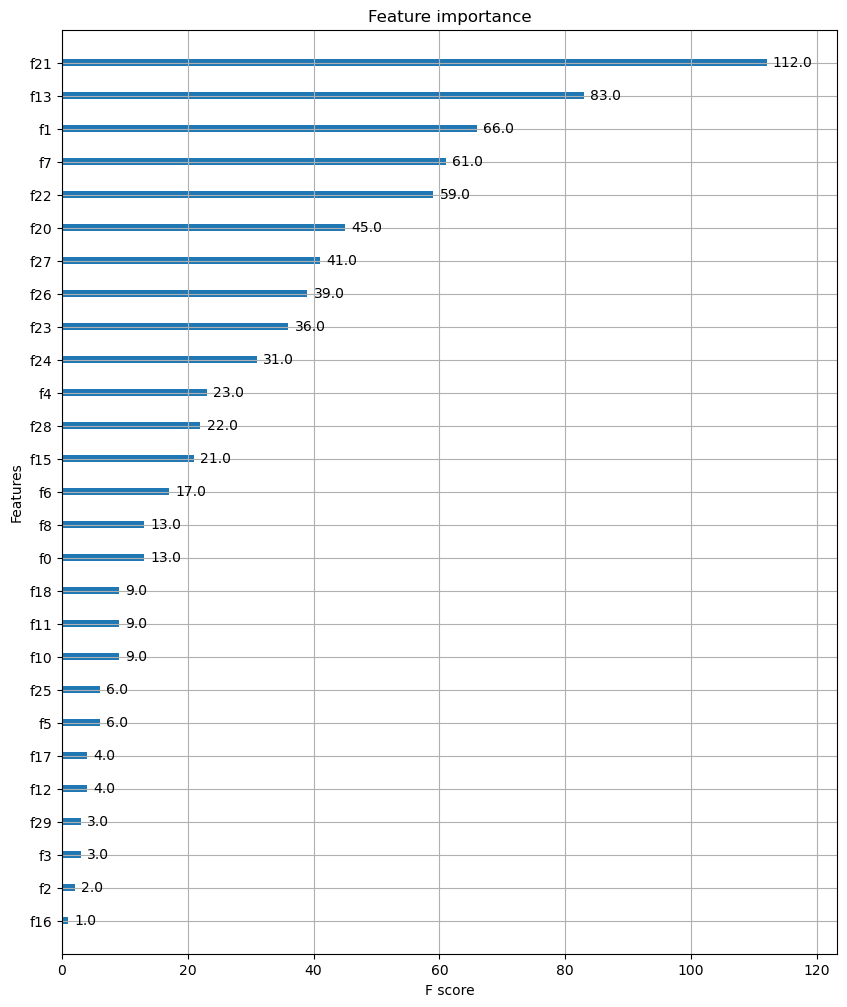

In [88]:
#시각화 기능 수행
import matplotlib.pyplot as plt
%matplotlib inline

# 피처 중요도 시각화 — XGBoost 모델이 분기에 가장 많이 사용한 피처 순으로 표시
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

## 사이킷런 래퍼 XGBoost

> `XGBClassifier`를 사용하면 sklearn의 `fit()`, `predict()`, `GridSearchCV` 등을 그대로 활용 가능.  
> DMatrix 변환 없이 DataFrame을 직접 입력할 수 있어 편의성이 높음.

In [86]:
from xgboost import XGBClassifier

# 사이킷런 래퍼: sklearn API와 동일하게 사용 가능
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)
xgb_wrapper.fit(X_train.values, y_train.values)
w_preds = xgb_wrapper.predict(X_test.values)
w_pred_proba = xgb_wrapper.predict_proba(X_test.values)[:, 1]
get_clf_eval(y_test, w_preds, w_pred_proba)

ValueError: Unable to avoid copy while creating an array as requested.
If using `np.array(obj, copy=False)` replace it with `np.asarray(obj)` to allow a copy when needed (no behavior change in NumPy 1.x).
For more details, see https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword.

In [89]:
#early stopping 수행
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)

# eval_set: 조기 종료에 사용할 검증 데이터
# early_stopping_rounds=100: 100회 연속 개선 없으면 학습 중단
evals = [(X_test, y_test)]
xgb_wrapper.fit(X_train, y_train, early_stopping_rounds=100,
                eval_metric="logloss", eval_set=evals, verbose=True)

ws100_preds = xgb_wrapper.predict(X_test)
ws100_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws100_preds, ws100_pred_proba)

AttributeError: module 'pandas' has no attribute 'Int64Index'

In [90]:
# early_stopping_rounds=10으로 줄여서 재학습
# 더 일찍 멈추므로 트리 수가 줄어들고 성능이 달라질 수 있음
xgb_wrapper.fit(X_train, y_train, early_stopping_rounds=10,
                eval_metric="logloss", eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

AttributeError: module 'pandas' has no attribute 'Int64Index'

> **early_stopping_rounds 비교**: 값이 클수록 더 오래 학습하고, 작을수록 일찍 종료됨.  
> 너무 작으면 충분히 학습하기 전에 멈춰 성능이 낮아질 수 있고, 너무 크면 과적합 위험이 있음.

NotFittedError: need to call fit or load_model beforehand

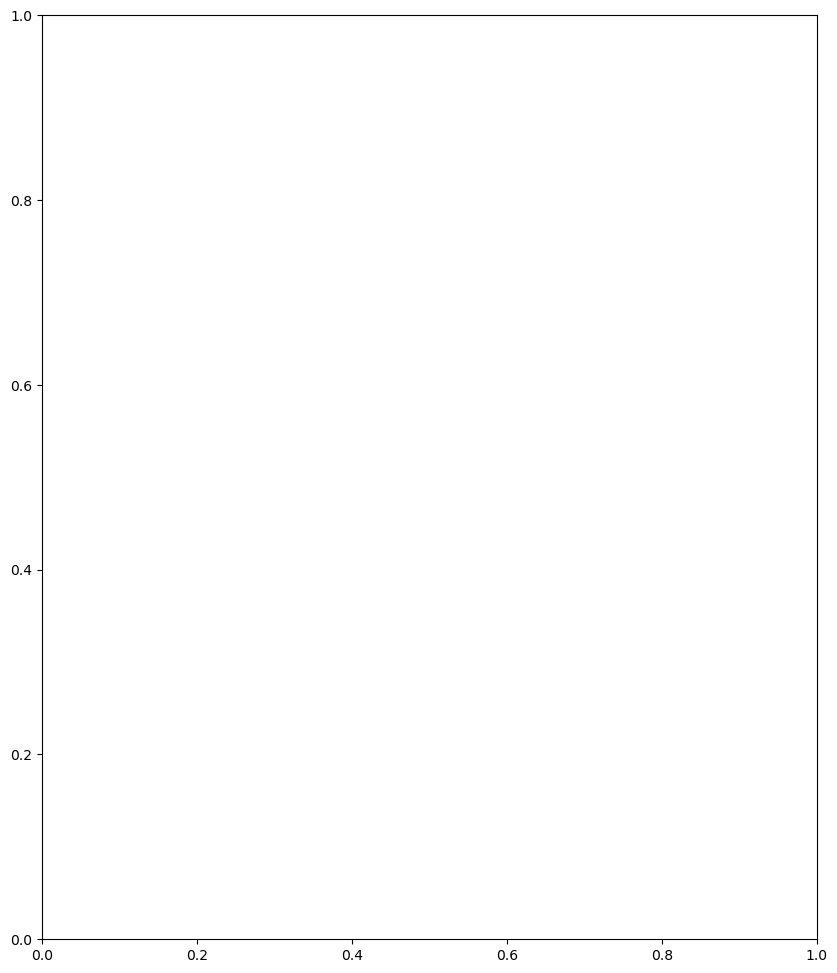

In [91]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

# 사이킷런 래퍼 클래스도 plot_importance에 직접 입력 가능
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_wrapper, ax=ax)

# 7. LightGBM
: XGBoost보다 학습 시간이 훨씬 적고, 메모리 사용량도 상대적으로 적음. 예측 성능은 비슷함.

: 적은 데이터 세트에 적용 시 과적합이 발생하기 쉬움. 일반적으로 10,000건 이하

: 일반 GBM계열 트리 분할 방법과 달리 리프 중심 트리 분할(Leaf Wise) 방식 사용. 

: 일반적인 균형 트리 분할(Level Wise) > 오버피팅에 더 강한 구조, 균형을 맞추기 위한 시간이 필요함

: LightGBM의 리프 중심 트리 > 균형을 맞추지 않고, 최대 손실 값을 가지는 리프 노드를 지속적으로 분할하여 규칙 트리 학습 반복

In [92]:
#LightGBM설치
!pip install lightgbm==3.3.2

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 10.2 MB/s  0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.6.0
    Uninstalling lightgbm-4.6.0:
      Successfully uninstalled lightgbm-4.6.0


In [96]:
#위스콘신 유방암 예측
!pip install lightgbm==3.3.5
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

dataset = load_breast_cancer()

cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 80% 학습 / 20% 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156)

# 학습 데이터를 다시 90% 학습 / 10% 검증으로 분할 — 조기 종료용 검증 세트
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156)

# LightGBM 모델 정의 및 조기 종료 적용
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

evals = [(X_tr, y_tr), (X_val, y_val)]
# early_stopping_rounds=50: 검증 logloss 50회 연속 개선 없으면 학습 중단
lgbm_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50,
                 eval_metric="logloss", eval_set=evals, verbose=True)

preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 8.5 MB/s  0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 3.3.2
    Uninstalling lightgbm-3.3.2:
      Successfully uninstalled lightgbm-3.3.2
[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_l

  You can safely remove it manually.


[55]	training's binary_logloss: 0.0659347	valid_1's binary_logloss: 0.264388
[56]	training's binary_logloss: 0.0636873	valid_1's binary_logloss: 0.263128
[57]	training's binary_logloss: 0.0613354	valid_1's binary_logloss: 0.26231
[58]	training's binary_logloss: 0.0591944	valid_1's binary_logloss: 0.262011
[59]	training's binary_logloss: 0.057033	valid_1's binary_logloss: 0.261454
[60]	training's binary_logloss: 0.0550801	valid_1's binary_logloss: 0.260746
[61]	training's binary_logloss: 0.0532381	valid_1's binary_logloss: 0.260236
[62]	training's binary_logloss: 0.0514074	valid_1's binary_logloss: 0.261586
[63]	training's binary_logloss: 0.0494837	valid_1's binary_logloss: 0.261797
[64]	training's binary_logloss: 0.0477826	valid_1's binary_logloss: 0.262533
[65]	training's binary_logloss: 0.0460364	valid_1's binary_logloss: 0.263305
[66]	training's binary_logloss: 0.0444552	valid_1's binary_logloss: 0.264072
[67]	training's binary_logloss: 0.0427638	valid_1's binary_logloss: 0.266223
[

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

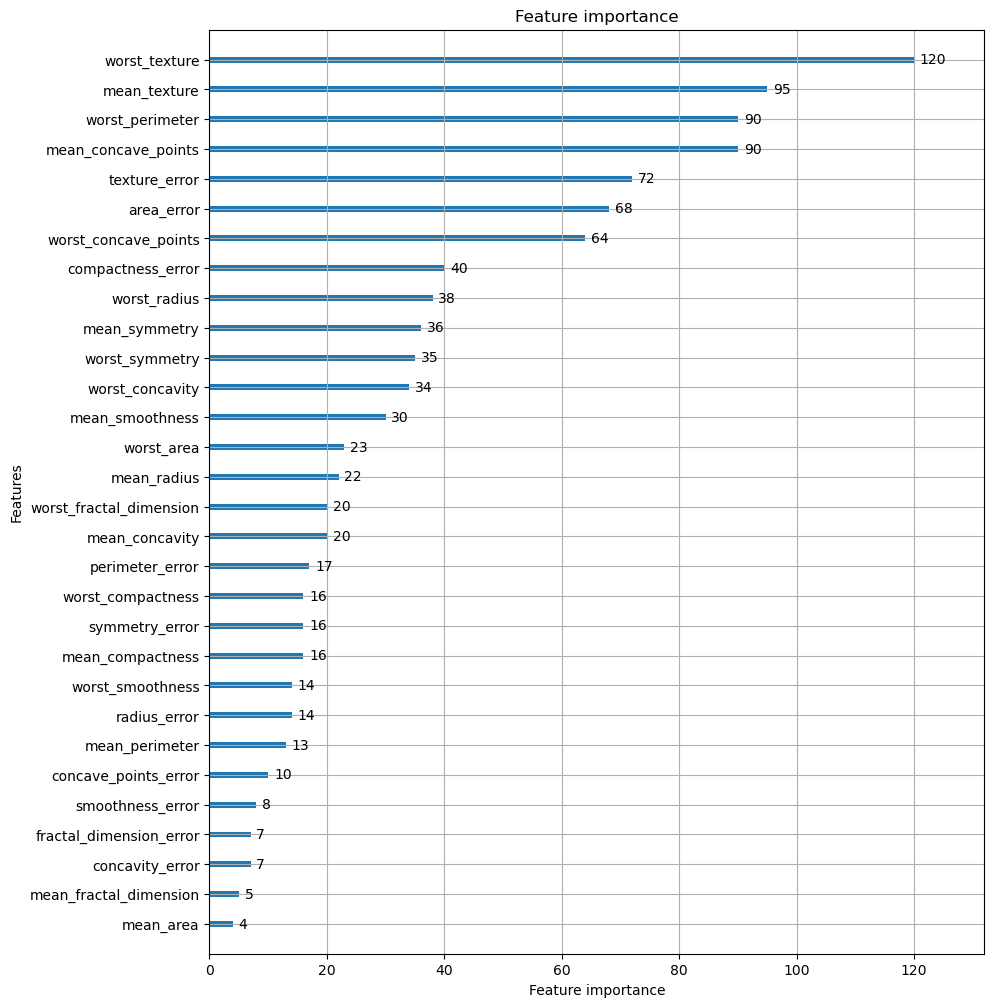

In [99]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

# LightGBM 피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

> **결과 해석**: XGBoost와 유사한 성능이지만 학습 속도가 훨씬 빠름.  
> 조기 종료 덕분에 400개로 설정했더라도 실제 사용된 트리 수는 더 적을 수 있음.  
> 피처 중요도는 XGBoost와 마찬가지로 분기에 많이 사용된 피처일수록 높게 나타남.

# 8. 베이지안 최적화 기반 HyperOpt 이용한 하이퍼 파라미터 튜닝
GridSearch: 튜닝할 하이퍼 파라미터 개수가 많을 경우 최적화 시간이 오래 걸림

베이지안 확률: 새로운 사건의 관측이나 새로운 샘플 데이터를 기반으로 사후 확률 개선

베이지안 최적화: 목적 함수 식을 제대로 알 수 없는 블랙박스 형태의 함수에서 최대 또는 최소 함수 반환 값을 만드는 최적 입력값을 최소시도를 통해 빠르게 찾음.
> 새로운 데이터를 입력받았을 때 최적 함수를 예측하는 사후 모델을 개선해 나가면서 최적 함수 모델 형성

대체 모델: 획득 함수로부터 최적함수 예측 가능 입력값을 추천받음. 이를 기반으로 최적 함수 모델 개선

획득 함수: 개선된 대체 모델 기반, 최적 입력값 계산. 이 입력값이 하이퍼 파라미터.

In [97]:
#HyperOpt 사용
!pip install hyperopt
import hyperopt
print(hyperopt.__version__)

0.2.7


In [61]:
from hyperopt import hp

# search_space: 탐색할 파라미터 범위 정의
# hp.quniform(name, low, high, q): low~high 사이에서 q 간격으로 이산 탐색
search_space = {'x': hp.quniform('x', -10, 10, 1), 'y': hp.quniform('y', -15, 15, 1) }

In [62]:
from hyperopt import STATUS_OK

# 목적 함수: fmin()이 최솟값을 찾으려 하므로 최소화하고 싶은 값을 반환해야 함
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y  # 이 값의 최솟값을 탐색
    return retval

In [63]:
from hyperopt import fmin, tpe, Trials
import numpy as np

trial_val = Trials()

# max_evals=5: 5번만 탐색해 최솟값 탐색 — 탐색 횟수가 적어 결과가 부정확할 수 있음
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest,
               max_evals=5, trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)

100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 308.39trial/s, best loss: -224.0]
best: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [64]:
trial_val = Trials()

# max_evals=20: 탐색 횟수를 늘려 더 정확한 최솟값 탐색
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest,
               max_evals=20, trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_02)

100%|███████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 334.26trial/s, best loss: -296.0]
best: {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [65]:
# Trials 객체에 저장된 탐색 결과 확인
# results: 각 시도별 {'loss': 목적함수 반환값, 'status': 상태} 딕셔너리 리스트
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


In [66]:
# vals: 각 시도별 입력 파라미터값 딕셔너리
print(trial_val.vals)

{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.float64(-0.0)], 'y': [np.float64(5.0), np.float64(10.0), np.float64(-2.0), np.float64(12.0), np.float64(1.0), np.float64(15.0), np.float64(7.0), np.float64(-10.0), np.float64(0.0), np.float64(-5.0), np.float64(-3.0), np.float64(2.0), np.float64(4.0), np.float64(10.0), np.float64(3.0), np.float64(3.0), np.float64(-14.0), np.float64(-8.0), np.float64(11.0), np.float64(-0.0)]}


In [67]:
import pandas as pd

# 탐색 결과를 DataFrame으로 정리해 시각적으로 확인
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

result_df = pd.DataFrame({
    'x': trial_val.vals['x'],
    'y': trial_val.vals['y'],
    'losses': losses
})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


## HyperOpt를 이용한 XGBoost 하이퍼파라미터 최적화

In [69]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156)

In [70]:
from hyperopt import hp

# XGBoost 탐색 공간 정의
# hp.quniform: 이산값 탐색 (정수형 변환 필요)
# hp.uniform: 연속값 탐색
xgb_search_space = {
    'max_depth': hp.quniform('max_depth', 5, 20, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
}

In [71]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
    # fmin()이 모든 값을 실수로 넘기므로 정수형 파라미터는 int()로 변환 필수
    xgb_clf = XGBClassifier(
        n_estimators=100,  # 수행 시간 절약을 위해 100으로 축소
        max_depth=int(search_space['max_depth']),
        min_child_weight=int(search_space['min_child_weight']),
        learning_rate=search_space['learning_rate'],
        colsample_bytree=search_space['colsample_bytree'],
        eval_metric='logloss'
    )
    accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    # 정확도는 높을수록 좋으므로 -1을 곱해 최솟값 탐색 문제로 변환
    return {'loss': -1 * np.mean(accuracy), 'status': STATUS_OK}

In [73]:
from hyperopt import fmin, tpe, Trials

trial_val = Trials()

# max_evals=50: 50회 탐색으로 최적 파라미터 탐색
best = fmin(fn=objective_func, space=xgb_search_space, algo=tpe.suggest,
            max_evals=50, trials=trial_val, rstate=np.random.default_rng(seed=9))

print('best:', best)

  0%|                                                                           | 0/50 [00:00<?, ?trial/s, best loss=?]

job exception: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\YOON\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\YOON\anaconda3\Lib\site-packages\xgboost\core.py", line 506, in inner_f
    return f(**kwargs)
  File "C:\Users\YOON\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1231, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        missing=self.missing,
        ^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
        label_transform=label_transfo

  0%|                                                                           | 0/50 [00:00<?, ?trial/s, best loss=?]


ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\YOON\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\YOON\anaconda3\Lib\site-packages\xgboost\core.py", line 506, in inner_f
    return f(**kwargs)
  File "C:\Users\YOON\anaconda3\Lib\site-packages\xgboost\sklearn.py", line 1231, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        missing=self.missing,
        ^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
        label_transform=label_transform,

In [75]:
#정수형 하이퍼 파라미터는 정수형으로 형 변환, 실수형 하이퍼 파라미터는 소수점 5자리까지 변환
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

NameError: name 'best' is not defined

In [76]:
# HyperOpt로 찾은 최적 파라미터로 최종 모델 학습
# n_estimators를 400으로 늘리고 조기 종료 적용
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5)
)

evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, early_stopping_rounds=50,
                eval_metric='logloss', eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

NameError: name 'best' is not defined